# Problem Set 6 — MIT 6.7220/15.084 Nonlinear Optimization (Spring 2026)
**Nikhilesh Belulkar**

---

## Problem 1: Proximal Gradient and Acceleration

Consider the $\ell_1$-regularized regression problem:
$$\min_x \; \frac{1}{2}\|Ax - b\|_2^2 + \lambda\|x\|_1 \tag{1}$$
where $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$, and $\lambda > 0$.

### Question 1 (10 points): Proximal Operator of $g(x) = \lambda|x|$

We want to find:
$$\text{prox}_g(x) = \arg\min_y \left\{ \lambda|y| + \frac{1}{2}(y - x)^2 \right\}$$

We consider three cases based on the sign of $y$.

---

**Case 1: $y > 0$**

The objective becomes $h(y) = \lambda y + \frac{1}{2}(y-x)^2$. Setting the derivative to zero:
$$\frac{\partial h}{\partial y} = \lambda + (y - x) = 0 \implies y^* = x - \lambda$$

This is valid only when $y^* \geq 0$, i.e., $x \geq \lambda$. Therefore $\text{prox}_g(x) = x - \lambda$ for $x \geq \lambda$.

---

**Case 2: $y < 0$**

The objective becomes $h(y) = -\lambda y + \frac{1}{2}(y-x)^2$. Setting the derivative to zero:
$$\frac{\partial h}{\partial y} = -\lambda + (y - x) = 0 \implies y^* = x + \lambda$$

This is valid only when $y^* \leq 0$, i.e., $x \leq -\lambda$. Therefore $\text{prox}_g(x) = x + \lambda$ for $x \leq -\lambda$.

---

**Case 3: $y = 0$**

We use the subdifferential optimality condition $0 \in \partial_y\!\left[\lambda|y| + \frac{1}{2}(y-x)^2\right]\!\big|_{y=0}$. Since $\partial|y|\big|_{y=0} = [-1, 1]$:
$$0 \in \lambda[-1, 1] + (0 - x) \iff x \in [-\lambda, \lambda]$$

Therefore $\text{prox}_g(x) = 0$ for $|x| \leq \lambda$.

---

**Result — Soft-Thresholding Operator $\mathcal{S}_\lambda$:**

$$\boxed{\text{prox}_g(x) = \mathcal{S}_\lambda(x) = \begin{cases} x - \lambda & \text{if } x > \lambda \\ 0 & \text{if } |x| \leq \lambda \\ x + \lambda & \text{if } x < -\lambda \end{cases}}$$

**Why is $\text{prox}_g$ called a soft-thresholding function?**

It provides a threshold $\lambda$: any input with $|x| \leq \lambda$ is mapped to exactly zero (shrunk all the way), while inputs outside $[-\lambda, \lambda]$ are shifted toward zero by $\lambda$. This is "soft" because values above the threshold are not kept unchanged (as in hard-thresholding) but are continuously shrunk—making $\mathcal{S}_\lambda$ a Lipschitz-continuous function whose subdifferential is well-defined everywhere, enabling clean optimization theory.

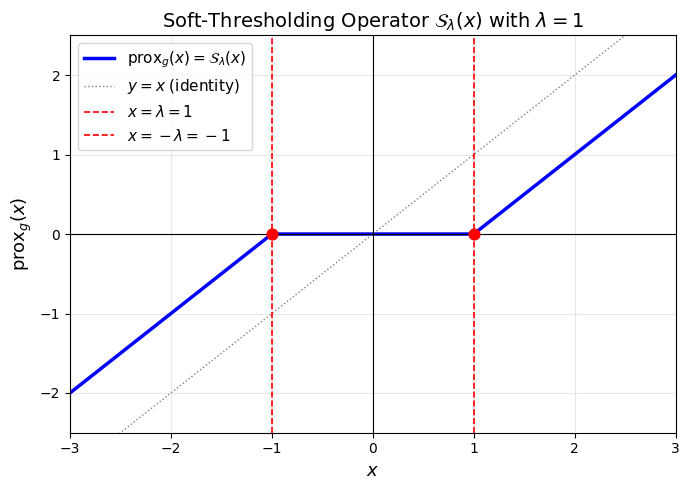

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def soft_threshold(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)

lam = 1.0
x_vals = np.linspace(-3, 3, 600)
y_vals = soft_threshold(x_vals, lam)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_vals, y_vals, 'b-', linewidth=2.5, label=r'$\mathrm{prox}_g(x) = \mathcal{S}_\lambda(x)$')
ax.plot(x_vals, x_vals, 'gray', linewidth=1, linestyle=':', label=r'$y = x$ (identity)')
ax.axhline(0, color='k', linewidth=0.8)
ax.axvline(0, color='k', linewidth=0.8)
ax.axvline(lam,  color='r', linestyle='--', linewidth=1.2, label=r'$x = \lambda = 1$')
ax.axvline(-lam, color='r', linestyle='--', linewidth=1.2, label=r'$x = -\lambda = -1$')
ax.scatter([-lam, lam], [0, 0], color='r', s=60, zorder=5)  # threshold points
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel(r'$\mathrm{prox}_g(x)$', fontsize=13)
ax.set_title(r'Soft-Thresholding Operator $\mathcal{S}_\lambda(x)$ with $\lambda = 1$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)
ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

### Question 2 (10 points): Separability of the Proximal Operator

**Claim:** If $f : \mathbb{R}^n \to \mathbb{R}$ is proper, closed, and convex with $f(x) = \sum_{i=1}^n g_i(x_i)$, where each $g_i : \mathbb{R} \to \mathbb{R}$ is proper, closed, and convex, then:
$$\text{prox}_f(x) = \left[\text{prox}_{g_i}(x_i)\right]_{i=1}^n$$

**Proof:**

By definition of the proximal operator:
$$\text{prox}_f(x) = \arg\min_{y \in \mathbb{R}^n} \left\{ f(y) + \frac{1}{2}\|y - x\|_2^2 \right\}$$

Substituting the separable form of $f$ and expanding the squared norm:
$$= \arg\min_{y} \left\{ \sum_{i=1}^n g_i(y_i) + \frac{1}{2}\sum_{i=1}^n (y_i - x_i)^2 \right\} = \arg\min_{y} \sum_{i=1}^n \left\{ g_i(y_i) + \frac{1}{2}(y_i - x_i)^2 \right\}$$

The objective is a sum of $n$ terms, each depending on a **distinct** coordinate $y_i$. Therefore the joint minimization fully decouples into $n$ independent scalar minimizations:
$$y_i^* = \arg\min_{y_i \in \mathbb{R}} \left\{ g_i(y_i) + \frac{1}{2}(y_i - x_i)^2 \right\} = \text{prox}_{g_i}(x_i), \qquad i = 1, \ldots, n$$

To see this rigorously, the first-order optimality condition for the full problem requires $0 \in \partial_y \phi(y)$, where $\phi(y) = \sum_{i=1}^n \left[g_i(y_i) + \frac{1}{2}(y_i - x_i)^2\right]$. Computing the subdifferential component-wise:
$$\partial_y \phi(y) = \begin{bmatrix} \partial g_1(y_1) + (y_1 - x_1) \\ \vdots \\ \partial g_n(y_n) + (y_n - x_n) \end{bmatrix}$$

Each component involves only $y_i$, so the condition $0 \in \partial_y \phi(y)$ holds if and only if, for each $i$:
$$0 \in \partial g_i(y_i) + (y_i - x_i)$$

which is exactly the optimality condition for $y_i = \text{prox}_{g_i}(x_i)$. Since $g_i$ is convex, each scalar problem has a unique solution. Assembling component-wise:

$$\boxed{\text{prox}_f(x) = \left[\text{prox}_{g_i}(x_i)\right]_{i=1}^n} \qquad \square$$

### Question 3 (5 points): Proximal Operator of $r(x) = \lambda\|x\|_1$

We write $r$ in separable form:
$$r(x) = \lambda\|x\|_1 = \sum_{i=1}^n \lambda|x_i| = \sum_{i=1}^n g_i(x_i), \qquad \text{where } g_i(t) = \lambda|t|$$

Each $g_i$ is the scaled absolute value from Question 1. Applying the separability result of Question 2:
$$\text{prox}_r(x) = \left[\text{prox}_{g_i}(x_i)\right]_{i=1}^n = \left[\mathcal{S}_\lambda(x_i)\right]_{i=1}^n$$

Therefore:
$$\boxed{\left(\text{prox}_r(x)\right)_i = \mathcal{S}_\lambda(x_i) = \begin{cases} x_i - \lambda & \text{if } x_i > \lambda \\ 0 & \text{if } |x_i| \leq \lambda \\ x_i + \lambda & \text{if } x_i < -\lambda \end{cases}} \qquad i = 1, \ldots, n$$

That is, the proximal operator of the $\ell_1$ norm applies soft-thresholding independently to each coordinate.

### Question 4 (10 points): Proximal Gradient Method for Problem (1)

We decompose the objective as $F(x) = f(x) + r(x)$ where:
- $f(x) = \frac{1}{2}\|Ax - b\|_2^2$ — smooth and convex
- $r(x) = \lambda\|x\|_1$ — nonsmooth but convex

**Gradient of the smooth part:**
$$\nabla f(x) = A^\top(Ax - b)$$

**Proximal gradient iteration** with constant step size $h > 0$:
$$x_{t+1} = \text{prox}_{hr}\!\left(x_t - h\nabla f(x_t)\right) = \text{prox}_{h\lambda\|\cdot\|_1}\!\left(x_t - h A^\top(Ax_t - b)\right)$$

Let $z_t = x_t - h A^\top(Ax_t - b)$ (the gradient step). Applying the soft-thresholding proximal operator from Question 3 with threshold $h\lambda$:

$$\boxed{x_{t+1} = \mathcal{S}_{h\lambda}(z_t), \qquad \text{where} \qquad (x_{t+1})_i = \begin{cases} (z_t)_i - h\lambda & \text{if } (z_t)_i > h\lambda \\ (z_t)_i + h\lambda & \text{if } (z_t)_i < -h\lambda \\ 0 & \text{if } |(z_t)_i| \leq h\lambda \end{cases}}$$

In words: take a gradient step on the smooth part $f$, then apply component-wise soft-thresholding at level $h\lambda$ to handle the $\ell_1$ penalty.

### Question 5 (5 points): Lipschitz Constant and Step Size

The smooth part of the composite objective is $f(x) = \frac{1}{2}\|Ax - b\|_2^2$.

Computing the Hessian:
$$\nabla^2 f(x) = A^\top A$$

The Lipschitz constant $L_f$ of the gradient $\nabla f$ is the smallest constant satisfying $\|\nabla f(x) - \nabla f(y)\|_2 \leq L_f\|x-y\|_2$ for all $x, y$. Since:
$$\|\nabla f(x) - \nabla f(y)\|_2 = \|A^\top A(x - y)\|_2 \leq \|A^\top A\|_2\,\|x - y\|_2$$

and $\|A^\top A\|_2 = \lambda_{\max}(A^\top A)$ (the spectral norm equals the largest eigenvalue for PSD matrices), we obtain:

$$\boxed{L_f = \lambda_{\max}(A^\top A) = \sigma_{\max}(A)^2}$$

where $\sigma_{\max}(A)$ is the largest singular value of $A$.

The constant step size that guarantees convergence of the proximal gradient method is:
$$h = \frac{1}{L_f} = \frac{1}{\lambda_{\max}(A^\top A)}$$

### Question 6 (10 points): Subgradient Method for Problem (1)

The full objective is $F(x) = \frac{1}{2}\|Ax - b\|_2^2 + \lambda\|x\|_1$.

**Subdifferential of $F$:**

Since $f(x) = \frac{1}{2}\|Ax-b\|_2^2$ is smooth and $r(x) = \lambda\|x\|_1$ is convex, by the sum rule:
$$\partial F(x) = \nabla f(x) + \lambda\,\partial\|x\|_1 = A^\top(Ax - b) + \lambda\, s$$

where $s \in \partial\|x\|_1$ has components:
$$s_i \in \begin{cases} \{\text{sign}(x_i)\} & \text{if } x_i \neq 0 \\ [-1, 1] & \text{if } x_i = 0 \end{cases}$$

A canonical subgradient is obtained by taking $s_i = \text{sign}(x_i)$ (with $\text{sign}(0) = 0$):
$$g = A^\top(Ax - b) + \lambda\,\text{sign}(x) \in \partial F(x)$$

**Subgradient iteration** at step $t$ with constant step size $h > 0$:

$$\boxed{x_{t+1} = x_t - h\,g_t, \qquad g_t = A^\top(Ax_t - b) + \lambda\,\text{sign}(x_t) \in \partial F(x_t)}$$

**Key observation:** Unlike the proximal gradient method, the subgradient method does **not** guarantee descent at every step — $F(x_{t+1})$ may be larger than $F(x_t)$. Convergence is tracked via the best iterate: $F_{\text{best}}^{(t)} = \min_{s \leq t} F(x_s)$.

---
## Problem 1, Question 7: Numerical Experiments

### Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Problem data ──────────────────────────────────────────────────────────────
m, n = 100, 110
lam  = 1.0

A      = np.random.randn(m, n)
x_true = np.zeros(n)
x_true[2] =  1.0   # e_3  (0-indexed)
x_true[6] = -1.0   # -e_7 (0-indexed)
b  = A @ x_true
x0 = np.ones(n)

# ── Helper functions ──────────────────────────────────────────────────────────
def F(x):
    """Full objective F(x) = (1/2)||Ax-b||^2 + λ||x||_1."""
    return (1/2)*((A@x-b).T@(A@x-b)) + lam*np.linalg.norm(x, 1)

def grad_f(x):
    """Gradient of smooth part: ∇f(x) = A^T(Ax - b)."""
    return A.T @ (A@x - b)

def soft_threshold(x, threshold):
    """Component-wise soft-thresholding S_threshold(x)."""
    return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)

# ── Lipschitz constant & step size (Q5) ──────────────────────────────────────
L_f    = np.linalg.eigvalsh(A.T @ A).max()
h_prox = 1 / L_f

# ── Surrogate for F* ──────────────────────────────────────────────────────────
F_star = F(x_true)

### (a) Subgradient Method with Polyak Step Size

$$x_{t+1} = x_t - h_t g_t, \qquad h_t = \frac{F(x_t) - F^*}{\|g_t\|^2} \quad (g_t \neq 0)$$

In [12]:
def subgradient_polyak(x0, T=200):
    x = x0.copy()
    F_vals, dist_vals = [], []

    for t in range(T):
        F_vals.append(F(x))
        dist_vals.append(np.linalg.norm(x - x_true))

        # TODO: compute subgradient g_t ∈ ∂F(x_t)
        g_t = grad_f(x)+lam*np.sign(x) # this feels wrong 

        # TODO: compute Polyak step size h_t = (F(x_t) - F*) / ||g_t||^2
        h_t = (F(x)-F_star)/np.linalg.norm(g_t)**2

        # TODO: update x
        x = x - h_t*g_t

    F_vals.append(F(x))
    dist_vals.append(np.linalg.norm(x - x_true))
    return np.array(F_vals), np.array(dist_vals)


F_sub, dist_sub = subgradient_polyak(x0)

### (b) Proximal Gradient Method

$$x_{t+1} = \mathcal{S}_{h\lambda}\!\left(x_t - h A^\top(Ax_t - b)\right), \qquad h = \frac{1}{L_f}$$

In [13]:
def proximal_gradient(x0, h, T=200):
    x = x0.copy()
    F_vals, dist_vals = [], []

    for t in range(T):
        F_vals.append(F(x))
        dist_vals.append(np.linalg.norm(x - x_true))

        z = x - h * grad_f(x)
        x = soft_threshold(z, h * lam)

    F_vals.append(F(x))
    dist_vals.append(np.linalg.norm(x - x_true))
    return np.array(F_vals), np.array(dist_vals)


F_prox, dist_prox = proximal_gradient(x0, h=h_prox)

### (c) Plots: $F(x_t) - F^*$ and $\|x_t - x_\text{true}\|_2$ over 200 iterations

F(x_true)       = 2.000000
F_star_refined  = 2.000000
Min gap sub     = 2.76e-05
Min gap prox    = 6.07e-01
Any negative gaps (sub)?  False
Any negative gaps (prox)? False


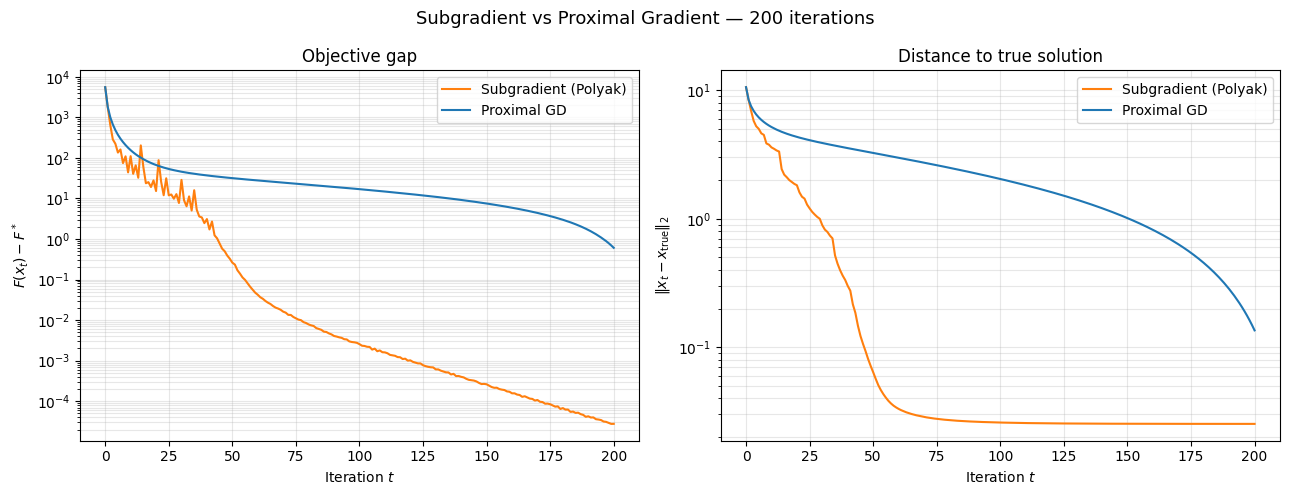

In [14]:
iters = np.arange(201)

# ── Use the best value found across all iterates as F* ────────────────────────
# F(x_true) is only a surrogate; the true minimum may be slightly lower.
# Taking the min over all iterates avoids negative gaps in semilogy.
F_star_refined = min(F_star, F_sub.min(), F_prox.min())

gap_sub  = F_sub  - F_star_refined
gap_prox = F_prox - F_star_refined

print(f"F(x_true)       = {F_star:.6f}")
print(f"F_star_refined  = {F_star_refined:.6f}")
print(f"Min gap sub     = {gap_sub.min():.2e}")
print(f"Min gap prox    = {gap_prox.min():.2e}")
print(f"Any negative gaps (sub)?  {(gap_sub  < 0).any()}")
print(f"Any negative gaps (prox)? {(gap_prox < 0).any()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(iters, np.maximum(gap_sub,  1e-12), label='Subgradient (Polyak)', color='tab:orange')
axes[0].semilogy(iters, np.maximum(gap_prox, 1e-12), label='Proximal GD',          color='tab:blue')
axes[0].set_xlabel('Iteration $t$')
axes[0].set_ylabel('$F(x_t) - F^*$')
axes[0].set_title('Objective gap')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(iters, dist_sub,  label='Subgradient (Polyak)', color='tab:orange')
axes[1].semilogy(iters, dist_prox, label='Proximal GD',          color='tab:blue')
axes[1].set_xlabel('Iteration $t$')
axes[1].set_ylabel(r'$\|x_t - x_\mathrm{true}\|_2$')
axes[1].set_title('Distance to true solution')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Subgradient vs Proximal Gradient — 200 iterations', fontsize=13)
plt.tight_layout()
plt.show()

### (d) Bonus: Accelerated Proximal Gradient (FISTA)

Initialize $x_0 = y_0$, $\alpha_0 = 1$. At each iteration:
$$x_{t+1} = \mathcal{S}_{h\lambda}(y_t - h\nabla f(y_t)), \qquad \alpha_{t+1} = \frac{1 + \sqrt{1 + 4\alpha_t^2}}{2}, \qquad y_{t+1} = x_{t+1} + \frac{\alpha_t - 1}{\alpha_t+1}(x_{t+1} - x_t)$$

In [15]:
def accelerated_proximal_gradient(x0, h, T=200):
    x     = x0.copy()
    y     = x0.copy()
    alpha = 1.0
    F_vals, dist_vals = [], []

    for t in range(T):
        F_vals.append(F(x))
        dist_vals.append(np.linalg.norm(x - x_true))

        x_new     = soft_threshold(y - h * grad_f(y), h * lam)
        alpha_new = (1 + np.sqrt(1 + 4 * alpha**2)) / 2          # α_{t+1}
        y_new     = x_new + ((alpha - 1) / alpha_new) * (x_new - x)  # momentum

        x     = x_new
        alpha = alpha_new
        y     = y_new

    F_vals.append(F(x))
    dist_vals.append(np.linalg.norm(x - x_true))
    return np.array(F_vals), np.array(dist_vals)


F_fista, dist_fista = accelerated_proximal_gradient(x0, h=h_prox)

### (e) Bonus: All Three Algorithms Compared

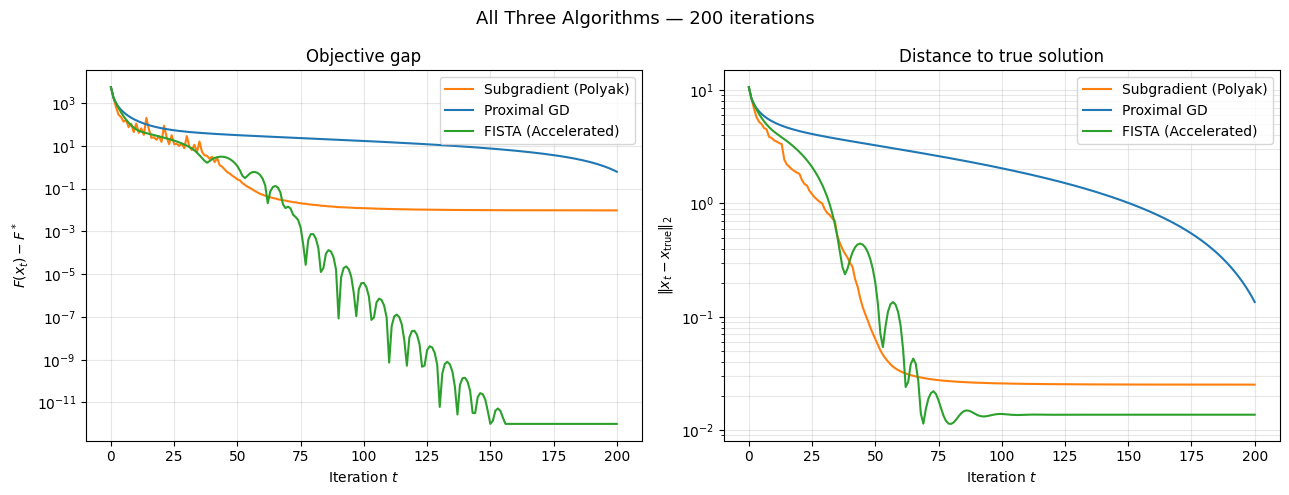

In [16]:
F_star_refined = min(F_star, F_sub.min(), F_prox.min(), F_fista.min())

gap_sub   = np.maximum(F_sub   - F_star_refined, 1e-12)
gap_prox  = np.maximum(F_prox  - F_star_refined, 1e-12)
gap_fista = np.maximum(F_fista - F_star_refined, 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(iters, gap_sub,   label='Subgradient (Polyak)', color='tab:orange')
axes[0].semilogy(iters, gap_prox,  label='Proximal GD',          color='tab:blue')
axes[0].semilogy(iters, gap_fista, label='FISTA (Accelerated)',   color='tab:green')
axes[0].set_xlabel('Iteration $t$')
axes[0].set_ylabel('$F(x_t) - F^*$')
axes[0].set_title('Objective gap')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(iters, dist_sub,   label='Subgradient (Polyak)', color='tab:orange')
axes[1].semilogy(iters, dist_prox,  label='Proximal GD',          color='tab:blue')
axes[1].semilogy(iters, dist_fista, label='FISTA (Accelerated)',   color='tab:green')
axes[1].set_xlabel('Iteration $t$')
axes[1].set_ylabel(r'$\|x_t - x_\mathrm{true}\|_2$')
axes[1].set_title('Distance to true solution')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('All Three Algorithms — 200 iterations', fontsize=13)
plt.tight_layout()
plt.show()

---
## Problem 2: Self-Concordance Theory

### Question 1 (10 points): Self-concordance of $f(x) = -\log(1 - \|x\|_2^2)$

**Claim:** $f(x) = -\log(1 - \|x\|_2^2)$ is self-concordant on $\Omega = \{x : \|x\|_2 < 1\}$.

**Proof.**

By the 1D characterisation, it suffices to fix any $x \in \Omega$ and $d \in \mathbb{R}^n$ and show that the line restriction
$$\varphi(\lambda) = f(x + \lambda d) = -\log\!\left(1 - \|x + \lambda d\|_2^2\right)$$
satisfies $(\varphi'''(\lambda))^2 \leq 4\,(\varphi''(\lambda))^3$ at $\lambda = 0$.

**Step 1: Derivatives of $r(\lambda) = 1 - \|x + \lambda d\|_2^2$.**

$$r'(\lambda) = -2(x + \lambda d)^\top d, \qquad r''(\lambda) = -2\|d\|_2^2, \qquad r'''(\lambda) = 0.$$

**Step 2: Express $\varphi''$ and $\varphi'''$ via $r$.** Since $\varphi = -\log r$:

$$\varphi''(\lambda) = \frac{(r'(\lambda))^2}{r(\lambda)^2} - \frac{r''(\lambda)}{r(\lambda)}, \qquad \varphi'''(\lambda) = -\frac{2(r'(\lambda))^3}{r(\lambda)^3} + \frac{3r'(\lambda)r''(\lambda)}{r(\lambda)^2}.$$

**Step 3: Evaluate at $\lambda = 0$.** Define $s = 1 - \|x\|_2^2 > 0$, $\;a = x^\top d$, $\;b = \|d\|_2^2$. Then $r(0) = s$, $r'(0) = -2a$, $r''(0) = -2b$, so:

$$\varphi''(0) = \frac{4a^2}{s^2} + \frac{2b}{s} = \frac{2(2a^2 + bs)}{s^2},$$

$$\varphi'''(0) = -\frac{2(-2a)^3}{s^3} + \frac{3(-2a)(-2b)}{s^2} = \frac{-16a^3 + 12abs}{s^3} = \frac{4a(4a^2 + 3bs)}{s^3}.$$

**Step 4: Verify $(\varphi'''(0))^2 \leq 4(\varphi''(0))^3$.** Substituting and cancelling positive powers of $s$, the inequality reduces to:

$$A(4A + 3B)^2 \leq 2(2A + B)^3, \qquad A = a^2 \geq 0,\quad B = bs \geq 0.$$

Expanding the difference:
$$2(2A + B)^3 - A(4A + 3B)^2 = B^2(3A + 2B) \geq 0,$$

which holds since $A, B \geq 0$. Therefore $(\varphi'''(0))^2 \leq 4(\varphi''(0))^3$ for all $x \in \Omega$ and $d \in \mathbb{R}^n$, so $f$ is self-concordant on $\Omega$. $\blacksquare$

---

### Question 2 (10 points): Newton Convergence Rate

**Claim.** Suppose $f$ is self-concordant and $x^*$ is its minimizer. If $e_t := \|x_t - x^*\|_{x_t} < 1/2$, then one Newton step $x_{t+1} = x_t + n(x_t)$ satisfies:
$$\|x_{t+1} - x^*\|_{x_t} \leq \frac{e_t^2}{1 - e_t}$$

**Why the condition $e_t < 1/2$ is necessary.** The condition does two separate jobs:

1. **Validity of the cubic bound ($e_t < 1$ required).** The gradient-level cubic bound used in the proof is derived by integrating the self-concordance condition along the path from $x_t$ to $x^*$, using Hessian stability at each intermediate point. Hessian stability requires all intermediate points to lie strictly inside the Dikin ellipsoid of radius 1 around $x_t$, i.e., $\|x^* - x_t\|_{x_t} < 1$. If $e_t \geq 1$ the denominator $1 - e_t \leq 0$ and the bound is undefined. So the proof breaks down entirely outside the unit Dikin ellipsoid.

2. **Contraction ($e_t < 1/2$ required).** Even with the bound valid, it only guarantees actual progress if the new error is strictly smaller than the old:
$$\frac{e_t^2}{1-e_t} < e_t \iff e_t < 1 - e_t \iff e_t < \frac{1}{2}$$
For $1/2 \leq e_t < 1$ the bound is finite but may exceed $e_t$, so Newton gives no improvement guarantee. The threshold $1/2$ is exactly where the bound transitions from contractive to non-contractive.

This reflects the two-phase structure of Newton's method: a **global phase** ($e_t \geq 1/2$) with no convergence guarantee (requiring line search or trust region), and a **local phase** ($e_t < 1/2$) with guaranteed quadratic-rate contraction.

**Why triangle inequality fails.** A natural first attempt: write $x_{t+1} - x^* = (x_t - x^*) + n(x_t)$ and apply the triangle inequality:
$$\|x_{t+1} - x^*\|_{x_t} \leq \|x_t - x^*\|_{x_t} + \|n(x_t)\|_{x_t} = e_t + \lambda(x_t)$$
This gives a bound strictly larger than $e_t$ — no contraction. The triangle inequality is tight when $n(x_t)$ and $(x_t - x^*)$ point in the same direction, but near a minimizer Newton's step is designed to cancel the error: $n(x_t) \approx -(x_t - x^*)$. Splitting them apart discards this cancellation entirely.

---

**Proof.**

**Step 1: Express $x_{t+1} - x^*$ as a pure remainder term.**

Let $H = \nabla^2 f(x_t)$. Substituting the Newton step $n(x_t) = -H^{-1}\nabla f(x_t)$:
$$x_{t+1} - x^* = (x_t - x^*) - H^{-1}\nabla f(x_t)$$

Since $x^*$ is the minimizer, $\nabla f(x^*) = 0$, so $\nabla f(x_t) = \nabla f(x_t) - \nabla f(x^*)$. Split this gradient difference into its linear part and nonlinear remainder $\rho$:
$$\nabla f(x_t) - \nabla f(x^*) = H(x_t - x^*) + \underbrace{\bigl[\nabla f(x_t) - \nabla f(x^*) - H(x_t - x^*)\bigr]}_{\rho}$$

Substituting:
$$x_{t+1} - x^* = (x_t - x^*) - H^{-1}\bigl[H(x_t - x^*) + \rho\bigr] = -H^{-1}\rho$$

The leading error terms cancel exactly. If $f$ were quadratic, $\rho = 0$ and Newton would converge in one step — all error comes from the non-quadratic deviation $\rho$.

**Step 2: Bound the remainder using the gradient-level cubic bound.**

For a self-concordant function, integrating the polarized condition $|D^3f(x)[u,v,w]| \leq 2\|u\|_x\|v\|_x\|w\|_x$ twice along the path from $x_t$ to $x^*$ yields the gradient-level cubic bound, valid for $r = \|y-x\|_x < 1$:
$$\|\nabla f(y) - \nabla f(x) - \nabla^2 f(x)(y-x)\|_{x,*} \leq \frac{r^2}{1-r}$$

(The pset's stated cubic bound $|f(y)-q_x(y)| \leq r^3/3(1-r)$ follows by integrating this gradient bound once more, using $\int_0^1 t^2/(1-tr)\,dt \leq 1/3(1-r)$.)

Taking the $x_t$-norm of $x_{t+1} - x^* = -H^{-1}\rho$ and using $\|H^{-1}g\|_{x_t} = \|g\|_{x_t,*}$:
$$\|x_{t+1} - x^*\|_{x_t} = \|\rho\|_{x_t,*} = \|\nabla f(x_t) - \nabla f(x^*) - H(x_t - x^*)\|_{x_t,*}$$

Applying the gradient-level cubic bound with $r = e_t < 1/2 < 1$:

$$\boxed{\|x_{t+1} - x^*\|_{x_t} \leq \frac{e_t^2}{1 - e_t} \leq 2e_t^2 \ll e_t} \qquad \square$$

---

**Why this does not immediately imply quadratic convergence.**

The bound measures the new error in the *old* norm $\|\cdot\|_{x_t}$. Quadratic convergence requires $\|x_{t+1} - x^*\|_{x_{t+1}} \leq C e_t^2$, with the norm at the *new* point $x_{t+1}$.

Applying the local-norm change theorem with $r = \lambda(x_t) = \|x_{t+1} - x_t\|_{x_t}$:
$$\|x_{t+1} - x^*\|_{x_{t+1}} \leq \frac{1}{1 - \lambda(x_t)}\|x_{t+1} - x^*\|_{x_t} \leq \frac{e_t^2}{(1-e_t)(1-\lambda(x_t))}$$

This still contains $\lambda(x_t)$, the Newton decrement, which is not directly controlled by $e_t$ alone without further work. Bonus Q3 closes this gap by showing $\lambda(x_{t+1}) \leq \left(\frac{\lambda(x_t)}{1-\lambda(x_t)}\right)^2$, from which true quadratic convergence of the Newton decrement follows.

---

### Bonus Question 3 (15 points): Quadratic Convergence of the Newton Decrement

**Claim.** If $\lambda(x_t) < 1$, then after one Newton step:
$$\lambda(x_{t+1}) \leq \left(\frac{\lambda(x_t)}{1 - \lambda(x_t)}\right)^2$$

This shows the Newton decrement converges quadratically, which (combined with Q2) establishes true quadratic convergence.

---

**Proof.**

Let $H = \nabla^2 f(x_t)$, $\lambda_t = \lambda(x_t)$.

**Step 1: Bound $\|\nabla f(x_{t+1})\|_{x_t,*}$ in the old local norm.**

Apply the gradient-level cubic bound (from the derivation in Q2) at $x = x_t$, $y = x_{t+1}$, with $r = \|x_{t+1} - x_t\|_{x_t} = \lambda_t$:
$$\|\nabla f(x_{t+1}) - \nabla f(x_t) - H(x_{t+1} - x_t)\|_{x_t,*} \leq \frac{\lambda_t^2}{1 - \lambda_t}$$

Now observe: by the Newton step optimality condition, $\nabla q_{x_t}(x_{t+1}) = 0$, i.e.:
$$\nabla f(x_t) + H(x_{t+1} - x_t) = 0$$

So the "remainder" is exactly $\nabla f(x_{t+1}) - 0 = \nabla f(x_{t+1})$, and the bound gives:
$$\|\nabla f(x_{t+1})\|_{x_t,*} \leq \frac{\lambda_t^2}{1-\lambda_t}$$

**Step 2: Convert to the new local norm using local-norm change.**

Apply the local-norm change theorem (from the pset) with $r = \|x_{t+1} - x_t\|_{x_t} = \lambda_t < 1$:
$$\|g\|_{x_{t+1},*} \leq \frac{1}{1 - \lambda_t}\|g\|_{x_t,*} \quad \text{for any } g$$

Taking $g = \nabla f(x_{t+1})$ and combining with Step 1:
$$\lambda(x_{t+1}) = \|\nabla f(x_{t+1})\|_{x_{t+1},*} \leq \frac{1}{1-\lambda_t} \cdot \frac{\lambda_t^2}{1-\lambda_t} = \frac{\lambda_t^2}{(1-\lambda_t)^2}$$

$$\boxed{\lambda(x_{t+1}) \leq \left(\frac{\lambda(x_t)}{1 - \lambda(x_t)}\right)^2} \qquad \square$$

**Quadratic convergence.** For $\lambda_t < 1/2$, we have $\frac{\lambda_t}{1-\lambda_t} < 2\lambda_t$, so $\lambda_{t+1} \leq 4\lambda_t^2$. The Newton decrement contracts quadratically. Combined with Q2, which bounds the iterate error $e_{t+1} \leq e_t^2/(1-e_t)$ in the old norm, and the local-norm change theorem to convert norms:

$$\|x_{t+1} - x^*\|_{x_{t+1}} \leq \frac{\|x_{t+1} - x^*\|_{x_t}}{1 - \lambda_t} \leq \frac{e_t^2}{(1-e_t)(1-\lambda_t)}$$

Since both $e_t$ and $\lambda_t$ shrink quadratically once below $1/2$, this gives genuine quadratic convergence $\|x_{t+1} - x^*\|_{x_{t+1}} = O(\|x_t - x^*\|_{x_t}^2)$.

---

### Bonus Question 4 (15 points): Self-Concordant + Bounded Below $\Rightarrow$ Has Minimizer

**Claim.** If $f$ is self-concordant on $\mathbb{R}^n$ and $f^* = \inf_x f(x) > -\infty$, then $f$ attains its minimum.

---

**Key tool: 1D lower bound (derived from self-concordance).**

For any $x$, unit vector $v$ with $\|v\|_x = 1$, and $t \geq 0$, the self-concordance condition implies $\phi(t) = f(x + tv)$ satisfies $|\phi'''(t)| \leq 2(\phi''(t))^{3/2}$. Setting $u(t) = \phi''(t)^{-1/2}$, this gives $|u'(t)| \leq 1$, so $u$ is 1-Lipschitz. Since $u(0) = 1$, we get $u(t) \leq 1 + t$, i.e., $\phi''(t) \geq (1+t)^{-2}$ for all $t \geq 0$. Integrating twice:

$$f(x + tv) \geq f(x) + t\langle\nabla f(x), v\rangle + t - \ln(1+t) \qquad \forall\, t \geq 0 \tag{$\star$}$$

Unlike the cubic bound, this holds for **all** $t \geq 0$, not just $t < 1$.

---

**Proof.**

The proof has two phases: first reach the quadratic convergence regime ($\lambda < 1/2$) using bounded-below, then close with Q3.

**Phase 1: Reach $\lambda(x) < 1/2$ in finitely many steps.**

Starting from any $x_0$, run the *damped Newton method*: at each step, if $\lambda(x_k) \geq 1/2$, take
$$x_{k+1} = x_k - \frac{1}{1+\lambda(x_k)}\,H_k^{-1}\nabla f(x_k), \qquad \alpha_k = \frac{1}{1+\lambda(x_k)}$$

Apply the 1D bound $(\star)$ in the Newton direction $v = n(x_k)/\lambda(x_k)$, $\|v\|_{x_k} = 1$, at $t = \alpha_k \lambda(x_k) = \lambda_k/(1+\lambda_k)$. Using $\langle\nabla f(x_k), v\rangle = -\lambda_k$ and writing $s = \lambda_k/(1+\lambda_k) \in (0,1)$:

$$f(x_{k+1}) \leq f(x_k) - \lambda_k \cdot s + s - \ln(1+s) = f(x_k) - s\lambda_k + s - \ln(1+s)$$

Substituting $s = \lambda_k/(1+\lambda_k)$:
$$f(x_{k+1}) \leq f(x_k) - \left[\frac{\lambda_k^2}{1+\lambda_k} - \ln\!\left(1 + \frac{\lambda_k}{1+\lambda_k}\right)\right]$$

The term in brackets is strictly positive for $\lambda_k > 0$ and is at least $\delta_0 > 0$ whenever $\lambda_k \geq 1/2$. Since $f$ is bounded below by $f^*$, we cannot decrease $f$ by $\delta_0$ indefinitely — after at most $K = (f(x_0) - f^*)/\delta_0$ steps we must reach a point $x_1$ with $\lambda(x_1) < 1/2$.

**Phase 2: Quadratic convergence to the minimizer.**

From $x_1$ with $\lambda_1 := \lambda(x_1) < 1/2$, run undamped Newton. By Q3:
$$\lambda(x_{k+1}) \leq \left(\frac{\lambda(x_k)}{1-\lambda(x_k)}\right)^2 \leq (2\lambda(x_k))^2 = 4\lambda(x_k)^2$$

So $\lambda(x_k) \leq \lambda_1 \cdot (2\lambda_1)^{2^k - 1} \to 0$ double-exponentially fast.

**The iterates form a Cauchy sequence.** The step size at each iteration is $\|x_{k+1} - x_k\|_{x_k} = \lambda(x_k)$. Converting to the fixed $x_1$-norm via repeated application of local-norm change:

$$\sum_{k=1}^\infty \|x_{k+1} - x_k\|_{x_1} \leq \sum_{k=1}^\infty \frac{\lambda(x_k)}{\prod_{j=1}^{k-1}(1-\lambda(x_j))} \leq \frac{1}{1-2\lambda_1}\sum_{k=1}^\infty \lambda(x_k) < \infty$$

since $\sum_k \lambda(x_k)$ converges (it's dominated by a geometric-squared series). By completeness of $\mathbb{R}^n$, the sequence converges to some $x^*$.

**$x^*$ is the minimizer.** By continuity of $f$:
$$f(x^*) = \lim_{k\to\infty} f(x_k) = f^*$$

since $f(x_k) \searrow f^*$ throughout both phases. Therefore $x^*$ attains the infimum. $\blacksquare$